In [1]:
import os
import pandas as pd

# Main mesocosm filepath
meso_fp = 'data/mesocosm/AQUACOSM_VIMS-Ehux_CoreData-2.xlsx'

meso = pd.read_excel('data/mesocosm/AQUACOSM_VIMS-Ehux_CoreData-2.xlsx')
# Melt all bags into a column
meso = meso.melt(
    id_vars=['Taxonomic Group', 'Day'],
    value_vars=['Bag 1', 'Bag 2', 'Bag 3', 'Bag 4', 'Bag 5', 'Bag 6', 'Bag 7', 'Fjord'],
    var_name='Bag',
    value_name='Abundance'
)

# Ciliates are in sperate files per bag
cil_url = 'data/mesocosm/ciliates/Dataset '
cil_bagid = ['1', '2', '3', '4', '5', '6', '7', '8']

cil_list = []
for bag in cil_bagid:
    tmp = pd.read_csv(
        cil_url + bag + '.csv',
        header=None,
        names=['Day', 'Abundance']
    )
    tmp['Bag'] = "Bag " + bag  # tag each row with its bag id
    cil_list.append(tmp)

# Combine all the bags
cil = pd.concat(cil_list, ignore_index=True)
cil.replace(['Bag 8'], ['Fjord'], inplace=True)
cil['Taxonomic Group'] = 'Ciliates'
cil['Abundance'] = cil['Abundance']/1000

df = pd.concat([meso, cil])

df = df.loc[df['Bag'] == 'Bag 5']

In [2]:
import numpy as np

# All units are in cells/mL
ehux_density = df.loc[df['Taxonomic Group'] == 'Neuks_HighSS']['Abundance'].values
ehux_time = df.loc[df['Taxonomic Group'] == 'Neuks_HighSS']['Day'].values
log_ehux_density = np.log(ehux_density + 1e-9)

bacteria_density = df.loc[df['Taxonomic Group'] == 'Bacteria']['Abundance'].values
bacteria_time = df.loc[df['Taxonomic Group'] == 'Bacteria']['Day'].values
log_bacteria_density = np.log(bacteria_density + 1e-9)

virus_density = df.loc[df['Taxonomic Group'] == 'EhV']['Abundance'].values
virus_time = df.loc[df['Taxonomic Group'] == 'EhV']['Day'].values
log_virus_density = np.log(virus_density + 1e-9)

ciliate_density = df.loc[df['Taxonomic Group'] == 'Ciliates']['Abundance'].values
ciliate_time = df.loc[df['Taxonomic Group'] == 'Ciliates']['Day'].values
log_ciliate_density = np.log(ciliate_density + 1e-9)

n1, n2, n3, n4 = len(ehux_time), len(bacteria_time), len(virus_time), len(ciliate_time)

In [3]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# colors = ['#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00', '#CC79A7', '#000000']
# fig, ax = plt.subplots(figsize=(6.5, 3.5))
# sns.lineplot(x=ehux_time, y=ehux_density, ax=ax, label='G. huxleyi', c=colors[2])
# sns.lineplot(x=bacteria_time, y=bacteria_density, ax=ax, label='Bacteria', c=colors[4])
# sns.lineplot(x=virus_time, y=virus_density, ax=ax, label='EhV', c=colors[6])
# sns.lineplot(x=ciliate_time, y=ciliate_density, ax=ax, label='Ciliates', c=colors[0])
# ax.set_yscale('log')
# ax.set_ylabel('Abundance (cells/mL)')
# ax.set_xlabel('Day')
# plt.legend(loc='best', fontsize=8)
# plt.tight_layout()
# plt.savefig('figures/mesocosm_observed_data.pdf', dpi=600, bbox_inches='tight')
# plt.savefig('figures/mesocosm_observed_data.png', dpi=600, bbox_inches='tight')
# plt.show()

In [4]:
def general_case(t, y, params):
    P, I, D, B, V, Z = np.maximum(y, 0.0)
    mu_P, k_P, delta_P, mu_B, k_B, beta_B, rho, lambda_D, beta_V, phi_V, k_V, Gmax, k_m, theta_Z, lambda_I = params

    phi_B = rho * (D + I)
    graz  = Gmax * P / (k_m + P) * Z

    dPdt = mu_P * P * (1 - P / k_P) - delta_P * P - phi_B * P * B - phi_V * P * V - graz
    dIdt = phi_V * P * V - lambda_I * I
    dDdt = delta_P * P + phi_B * P * B - lambda_D * D
    dBdt = mu_B * B * (1 - B / k_B) + beta_B * phi_B * P * B
    dVdt = beta_V * lambda_I * I * (1 - V/ k_V)
    dZdt = theta_Z * graz

    return [dPdt, dIdt, dDdt, dBdt, dVdt, dZdt]

Here is where this case becomes unique. This ODE system is stiff. This happens when rates of change within a system vary drastically. This will cause the process to lock up if you don't use a proper sampler / solver. Here is how we chose to solve the issue. 

We are still going to use PyMC, however, instead of using the integrated solver we will use an external SciPy ODE solver to get around the stiffness issue. We declare a custom operator (**Op**) with one input vector (**itypes**) and one output matrix (**otypes**). It will be initialized with your observed times. **perform** is the default call for the runtime computation of the **Op**. See in Cell 5 how the parameters and inital values are passed to the **Op**. The first 4 are the parameters and last 3 are the initial conditions (**theta** and **y0**).

The solve_ivp call should follow this form. The inputs to the function are as follows:

**fun**: The ODE function(s)  
**t_span**: first and last time  
**y0**: Initial Values  
**t_eval**: exact time points the ODE will be evaluated at  
**method**: This is up to the user but for our case we chose LSODA. It auto-detects stiffness and switches between Adams (non-stiff) and BDF (stiff) methods.

Lastly, the output is transposed to match the form PyMC expects. 

In [5]:
import pytensor.tensor as pt
from pytensor.graph.op import Op
from scipy.integrate import solve_ivp


class SolveIVPWrapper(Op):
    itypes = [pt.dvector]
    otypes = [pt.dvector]

    def __init__(self, ode_func, t_obs_list, state_indices, n_params, rtol=1e-6, atol=1e-8, penalty=1e8):
        self.ode_func = ode_func
        self.t_obs_list = [np.asarray(t, dtype=float) for t in t_obs_list]
        self.state_indices = state_indices  # which sol.y row each t_obs_list entry corresponds to
        self.n_params = n_params
        self.rtol = rtol
        self.atol = atol
        self.penalty = penalty

        self.t_grid = np.unique(np.concatenate(self.t_obs_list))
        self.t_span = (self.t_grid.min(), self.t_grid.max())
        self._total_len = sum(len(t) for t in self.t_obs_list)

    def _solve(self, params, y0, method):
        try:
            return solve_ivp(
                self.ode_func, self.t_span, y0,
                t_eval=self.t_grid, method=method, args=(params,),
                rtol=self.rtol, atol=self.atol,
            )
        except Exception:
            return None

    def perform(self, node, inputs, outputs):
        (theta_y0,) = inputs
        params = theta_y0[: self.n_params]
        y0 = theta_y0[self.n_params:]

        sol = self._solve(params, y0, "LSODA")
        if sol is None or not sol.success or not np.all(np.isfinite(sol.y)):
            sol = self._solve(params, y0, "BDF")

        if sol is None or not sol.success or not np.all(np.isfinite(sol.y)):
            outputs[0][0] = np.full(self._total_len, self.penalty)
            return

        preds = [
            np.interp(t, self.t_grid, sol.y[idx])
            for t, idx in zip(self.t_obs_list, self.state_indices)
        ]
        outputs[0][0] = np.concatenate(preds)


# State order in general_case(): 0=P, 1=I, 2=D, 3=B, 4=V, 5=Z
ode_op = SolveIVPWrapper(
    general_case,
    t_obs_list=[ehux_time, bacteria_time, virus_time, ciliate_time],
    state_indices=[0, 3, 4, 5],
    n_params=15,
)

This is where we create the MCMC 'loop': Sample Priors -> Estimate ODE @ times -> check fit

First, proirs. You have all kinds of options. Uniform, normal, lognormal, halfnormal. It all depends on what you need. For our parameters we choose uniform priors. These uniform priors say, "we believe the proper value for the model will be equally likely within this range and WILL NOT be outside of it". For our initial conditions we choose a lognormal distribution. This says, "we believe our value is around some **x** given a normalesque strictly positive distribution". For our sigma terms (error), we choose a halfnormal distribution. This is usually used for your error or standard deviation since neither can be negative and you can tune how quickly it tails off. Below are the priors visualized. 

After the priors are declared the next function call will be for the solution of the model given its current estimates. Pay attention to the order in which you pass your priors!

The final functions are the likelihood estimations of the model's states. This is where the model tests how well it estimated the observed data. We pass it our log transformed estimated data, the sigma values from the iteration's sample, and log transformed observed data. Now just let PyMC simply work its magic!

In [6]:
import pymc as pm

with pm.Model() as model:
    mu_P     = pm.Uniform("mu_P", 0.3, 0.9)
    k_P      = pm.LogNormal("k_P",      mu=np.log(7.8e6),   sigma=0.4)
    delta_P  = pm.LogNormal("delta_P",  mu=np.log(5.0e-2),  sigma=0.4)
    mu_B     = pm.Uniform("mu_B", 0.2, 1.2)
    k_B      = pm.LogNormal("k_B",      mu=np.log(1.1e7),   sigma=0.4)
    beta_B   = pm.LogNormal("beta_B",   mu=np.log(2.5e1),   sigma=0.4)
    rho      = pm.LogNormal("rho",      mu=np.log(7.4e-14), sigma=0.4)
    lambda_D = pm.LogNormal("lambda_D", mu=np.log(3.0e-1),  sigma=0.4)
    beta_V   = pm.Uniform("beta_V", 200, 800)
    phi_V    = pm.LogNormal("phi_V",    mu=np.log(1.2e-8),  sigma=0.4)
    k_V      = pm.LogNormal("k_V",      mu=np.log(8.0e6),   sigma=0.4)
    Gmax     = pm.LogNormal("Gmax",     mu=np.log(6.9e-1),  sigma=0.4)
    k_m      = pm.LogNormal("k_m",      mu=np.log(1.2e1),   sigma=0.4)
    theta_Z  = pm.LogNormal("theta_Z",  mu=np.log(1.5e-1),  sigma=0.4)
    lambda_I = pm.LogNormal("lambda_I", mu=np.log(0.7),     sigma=0.4)

    P0       = pm.LogNormal("P0",       mu=np.log(1.0e2),   sigma=0.3)
    I0       = pm.LogNormal("I0",       mu=np.log(3.0e-1),  sigma=0.3)
    D0       = pm.LogNormal("D0",       mu=np.log(1.0e2),   sigma=0.2)
    B0       = pm.LogNormal("B0",       mu=np.log(3.0e6),   sigma=0.3)
    V0       = pm.LogNormal("V0",       mu=np.log(1.0e5),   sigma=0.3)
    Z0       = pm.LogNormal("Z0",       mu=np.log(2.6e1),   sigma=0.3)

    sigma_live     = pm.HalfNormal('sigma_live', 1)
    sigma_bacteria = pm.HalfNormal('sigma_bacteria', 1)
    sigma_virus    = pm.HalfNormal('sigma_virus', 1)
    sigma_ciliate  = pm.HalfNormal('sigma_ciliate', 1)

    # sigma_live     = 0.3 * np.log(10)
    # sigma_bacteria = 0.3 * np.log(10)
    # sigma_virus    = 0.3 * np.log(10)
    # sigma_ciliate  = 0.3 * np.log(10)

    theta_y0 = pt.stack([
        mu_P, k_P, delta_P, mu_B, k_B, beta_B, rho, lambda_D,
        beta_V, phi_V, k_V, Gmax, k_m, theta_Z, lambda_I,
        P0, I0, D0, B0, V0, Z0
    ])
    preds = ode_op(theta_y0)

    live          = preds[:n1]
    bacteria_pred = preds[n1:n1 + n2]
    virus         = preds[n1 + n2:n1 + n2 + n3]
    ciliate_pred  = preds[n1 + n2 + n3:]

    pm.Normal("Y_live",     mu=pm.math.log(live + 1e-9),          sigma=sigma_live,     observed=log_ehux_density)
    pm.Normal("Y_bacteria", mu=pm.math.log(bacteria_pred + 1e-9), sigma=sigma_bacteria, observed=log_bacteria_density)
    pm.Normal("Y_virus",    mu=pm.math.log(virus + 1e-9),         sigma=sigma_virus,    observed=log_virus_density)
    pm.Normal("Y_ciliate",  mu=pm.math.log(ciliate_pred + 1e-9),  sigma=sigma_ciliate,  observed=log_ciliate_density)


In [7]:
with model:
    trace = pm.sample(
        step=pm.DEMetropolisZ(), draws=30000, tune=15000, chains=4, cores=4,
        return_inferencedata=True,
    )

Multiprocess sampling (4 chains in 4 jobs)
DEMetropolisZ: [mu_P, k_P, delta_P, mu_B, k_B, beta_B, rho, lambda_D, beta_V, phi_V, k_V, Gmax, k_m, theta_Z, lambda_I, P0, I0, D0, B0, V0, Z0, sigma_live, sigma_bacteria, sigma_virus, sigma_ciliate]


Output()

Sampling 4 chains for 15_000 tune and 30_000 draw iterations (60_000 + 120_000 draws total) took 218 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Sampling: [B0, D0, Gmax, I0, P0, V0, Y_bacteria, Y_ciliate, Y_live, Y_virus, Z0, beta_B, beta_V, delta_P, k_B, k_P, k_V, k_m, lambda_D, lambda_I, mu_B, mu_P, phi_V, rho, sigma_bacteria, sigma_ciliate, sigma_live, sigma_virus, theta_Z]
/Users/jackson/miniforge3/envs/science/lib/python3.12/site-packages/arviz/plots/traceplot.py:223: UserWarning: rcParams['plot.max_subplots'] (20) is smaller than the number of variables to plot (21), generating only 20 plots
  warnings.warn(


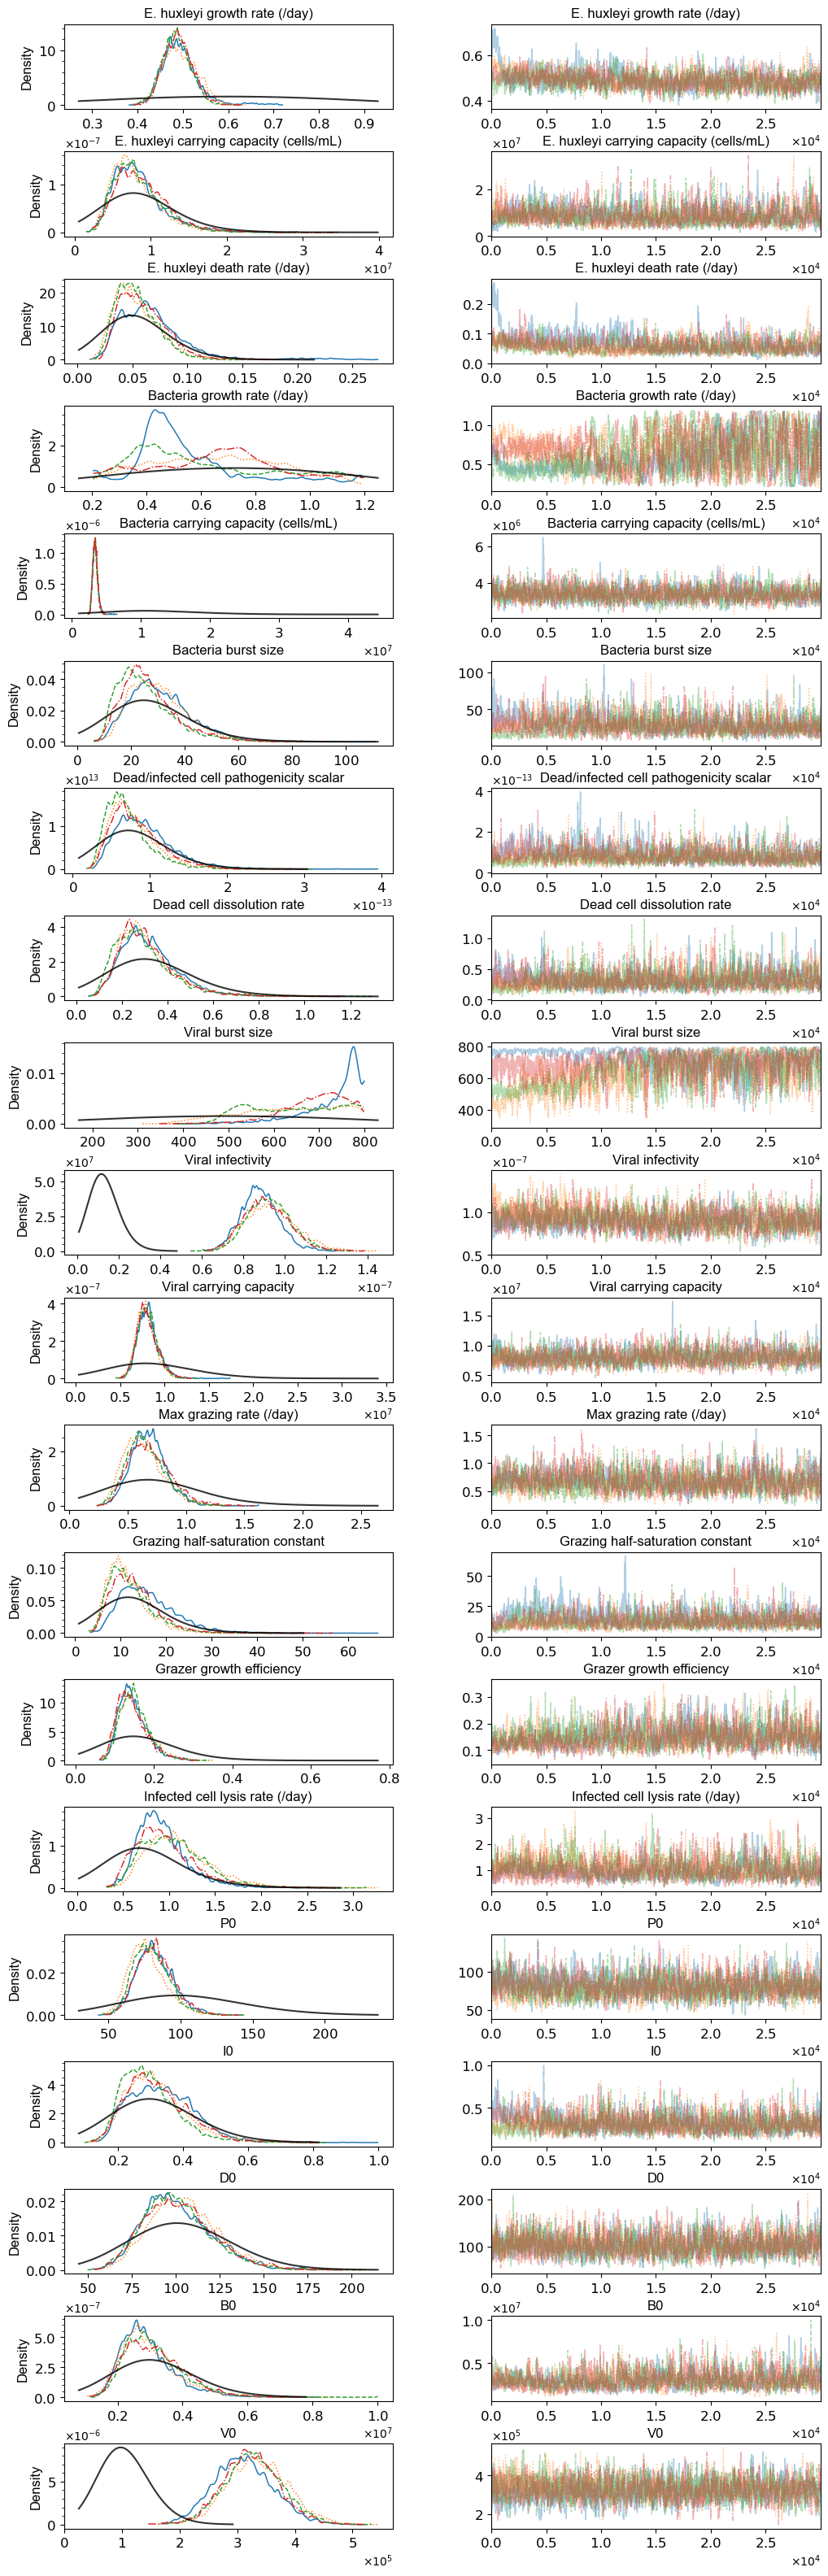

In [8]:
from utils.plot_utils_v2 import *

plot_trace(
    trace=trace, model=model,
    fontname='Arial', fontsize=12, num_prior_samples=2000,
    var_names_map={
        'mu_P': 'E. huxleyi growth rate (/day)', 'k_P': 'E. huxleyi carrying capacity (cells/mL)',
        'delta_P': 'E. huxleyi death rate (/day)', 'mu_B': 'Bacteria growth rate (/day)',
        'k_B': 'Bacteria carrying capacity (cells/mL)', 'beta_B': 'Bacteria burst size',
        'rho': 'Dead/infected cell pathogenicity scalar', 'lambda_D': 'Dead cell dissolution rate',
        'beta_V': 'Viral burst size', 'phi_V': 'Viral infectivity', 'k_V': 'Viral carrying capacity',
        'Gmax': 'Max grazing rate (/day)', 'k_m': 'Grazing half-saturation constant',
        'theta_Z': 'Grazer growth efficiency', 'lambda_I': 'Infected cell lysis rate (/day)',
    },
    var_order=['mu_P', 'k_P', 'delta_P', 'mu_B', 'k_B', 'beta_B', 'rho', 'lambda_D',
               'beta_V', 'phi_V', 'k_V', 'Gmax', 'k_m', 'theta_Z', 'lambda_I',
               'P0', 'I0', 'D0', 'B0', 'V0', 'Z0'],
    # save_path='figures/MCMC_mesocosm_chains.png',
)
plt.show()

In [26]:
def posterior_predictive_bands(trace, param_names, ode_func, t_dense, n_samples=300, seed=42):
    post = trace.posterior.stack(draws=("chain", "draw"))
    n_avail = post.sizes["draws"]
    rng = np.random.default_rng(seed)
    idx = rng.choice(n_avail, size=min(n_samples, n_avail), replace=False)

    all_names = param_names + ["P0", "I0", "D0", "B0", "V0", "Z0"]
    flat = {name: np.asarray(post[name].values).reshape(-1) for name in all_names}

    curves = {k: [] for k in ["P", "I", "D", "B", "V", "Z"]}
    t_span = (float(t_dense.min()), float(t_dense.max()))

    for i in idx:
        params = [flat[name][i] for name in param_names]
        y0 = [flat[name][i] for name in ["P0", "I0", "D0", "B0", "V0", "Z0"]]
        sol = None
        for method in ("LSODA", "BDF"):
            try:
                sol = solve_ivp(ode_func, t_span, y0, t_eval=t_dense, method=method,
                                 args=(params,), rtol=1e-6, atol=1e-8)
                if sol.success and np.all(np.isfinite(sol.y)):
                    break
            except Exception:
                sol = None
        if sol is None or not sol.success or not np.all(np.isfinite(sol.y)):
            continue
        for j, key in enumerate(["P", "I", "D", "B", "V", "Z"]):
            curves[key].append(sol.y[j])

    if len(curves["P"]) == 0:
        raise RuntimeError("All posterior-predictive solves failed.")

    bands = {}
    for key, arrs in curves.items():
        arr = np.array(arrs)
        bands[key + "_lo"]  = np.percentile(arr, 2.5, axis=0)
        bands[key + "_med"] = np.percentile(arr, 50, axis=0)
        bands[key + "_hi"]  = np.percentile(arr, 97.5, axis=0)
    return bands


t_max = max(ehux_time.max(), bacteria_time.max(), virus_time.max(), ciliate_time.max())
t_dense = np.linspace(0, t_max, 300)

PARAM_ORDER = ['mu_P', 'k_P', 'delta_P', 'mu_B', 'k_B', 'beta_B', 'rho', 'lambda_D',
               'beta_V', 'phi_V', 'k_V', 'Gmax', 'k_m', 'theta_Z', 'lambda_I']

bands = posterior_predictive_bands(trace, PARAM_ORDER, general_case, t_dense)

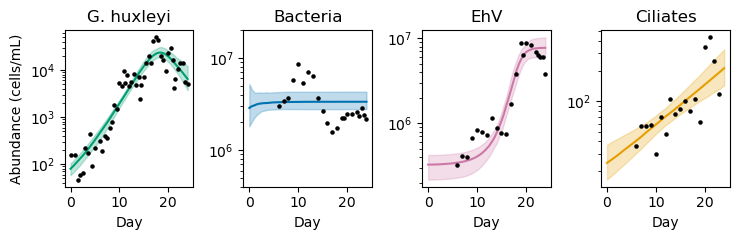

In [42]:
colors = ['#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00', '#CC79A7', '#000000']
COLOR_OBS = colors[7]

fig, axes = plt.subplots(1, 4, figsize=(7.5, 2.5))
labels = ['G. huxleyi', 'Bacteria', 'EhV', 'Ciliates']
obs_data = [
    (ehux_time, ehux_density, 'P', colors[2]),
    (bacteria_time, bacteria_density, 'B', colors[4]),
    (virus_time, virus_density, 'V', colors[6]),
    (ciliate_time, ciliate_density, 'Z', colors[0]),
]

for ax, label, (t_obs, y_obs, key, c_fit) in zip(axes, labels, obs_data):
    ax.scatter(t_obs, y_obs, color=COLOR_OBS, s=5, zorder=5, label='Observed')
    ax.plot(t_dense, bands[key + '_med'], color=c_fit, label='Posterior median')
    ax.fill_between(t_dense, bands[key + '_lo'], bands[key + '_hi'], color=c_fit, alpha=0.25)
    ax.set_title(label)
    ax.set_xlabel('Day')
    ax.set_ylabel('')
    ax.set_yscale('log')
axes[0].set_ylabel('Abundance (cells/mL)')
# axes[0].legend(frameon=False, fontsize=8, loc='best')
axes[1].set_ylim(4e5, 2e7)
# axes[2].set_ylim(2e5, 2e7)
plt.tight_layout()
plt.savefig('figures/mesocosm_trace.pdf', dpi=600, bbox_inches='tight')
plt.savefig('figures/mesocosm_trace.png', dpi=600, bbox_inches='tight')
plt.show()

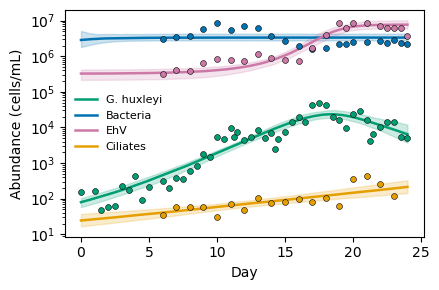

In [65]:
colors = ['#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00', '#CC79A7', '#000000']
COLOR_OBS = colors[7]

labels = ['G. huxleyi', 'Bacteria', 'EhV', 'Ciliates']
obs_data = [
    (ehux_time, ehux_density, 'P', colors[2]),
    (bacteria_time, bacteria_density, 'B', colors[4]),
    (virus_time, virus_density, 'V', colors[6]),
    (ciliate_time, ciliate_density, 'Z', colors[0]),
]

fig, ax = plt.subplots(figsize=(4.5, 3))

for label, (t_obs, y_obs, key, c_fit) in zip(labels, obs_data):
    ax.scatter(t_obs, y_obs, color=c_fit, s=18, zorder=5, edgecolor=COLOR_OBS, linewidth=0.4)
    ax.plot(t_dense, bands[key + '_med'], color=c_fit, lw=1.8, label=label)
    ax.fill_between(t_dense, bands[key + '_lo'], bands[key + '_hi'], color=c_fit, alpha=0.2)

ax.set_yscale('log')
ax.set_ylabel('Abundance (cells/mL)')
ax.set_xlabel('Day')
ax.legend(loc='best', fontsize=8, frameon=False)
plt.tight_layout()
plt.savefig('figures/mesocosm_trace.pdf', dpi=600, bbox_inches='tight')
plt.savefig('figures/mesocosm_trace.png', dpi=600, bbox_inches='tight')
plt.show()

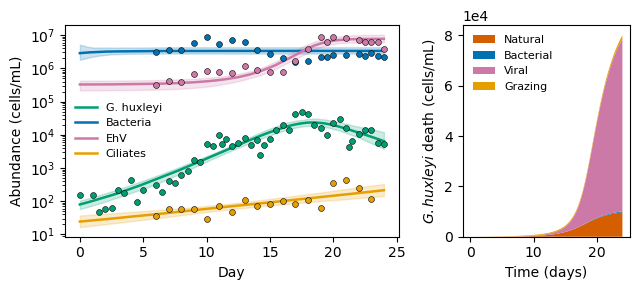

In [74]:
colors = ['#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00', '#CC79A7', '#000000']
COLOR_OBS = colors[7]

labels = ['G. huxleyi', 'Bacteria', 'EhV', 'Ciliates']
obs_data = [
    (ehux_time, ehux_density, 'P', colors[2]),
    (bacteria_time, bacteria_density, 'B', colors[4]),
    (virus_time, virus_density, 'V', colors[6]),
    (ciliate_time, ciliate_density, 'Z', colors[0]),
]

fig, ax = plt.subplots(1, 2, figsize=(6.5, 3), gridspec_kw={'width_ratios': [2, 1]})

for label, (t_obs, y_obs, key, c_fit) in zip(labels, obs_data):
    ax[0].scatter(t_obs, y_obs, color=c_fit, s=18, zorder=5, edgecolor=COLOR_OBS, linewidth=0.4)
    ax[0].plot(t_dense, bands[key + '_med'], color=c_fit, lw=1.8, label=label)
    ax[0].fill_between(t_dense, bands[key + '_lo'], bands[key + '_hi'], color=c_fit, alpha=0.2)

ax[0].set_yscale('log')
ax[0].set_ylabel('Abundance (cells/mL)')
ax[0].set_xlabel('Day')
ax[0].legend(loc='best', fontsize=8, frameon=False)

ax[1].stackplot(curves['t'], curves['D_nat'], curves['D_bact'], curves['D_vir'], curves['D_zoop'],
             labels=['Natural', 'Bacterial', 'Viral', 'Grazing'],
             colors=[colors[5], colors[4], colors[6], colors[0]])
# ax.set_title('Bag 1', fontsize=10)  # LATER: f'{bag_id} ({treat})' once looping
ax[1].set_xlabel('Time (days)', fontsize=10)
ax[1].set_ylabel(r'$\it{G. huxleyi}$ death (cells/mL)', fontsize=10)
ax[1].ticklabel_format(style='sci', scilimits=(0, 0), axis='y')
ax[1].legend(loc='best', frameon=False, fontsize=8)

# plt.xticks(fontsize=6)
# plt.yticks(fontsize=6)
plt.tight_layout()
plt.savefig('figures/bag5_trace_signature.pdf', dpi=600, bbox_inches='tight')
plt.savefig('figures/bag5_trace_signature.png', dpi=600, bbox_inches='tight')
plt.show()

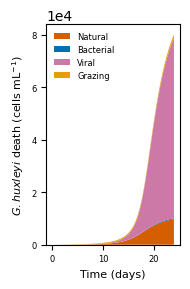

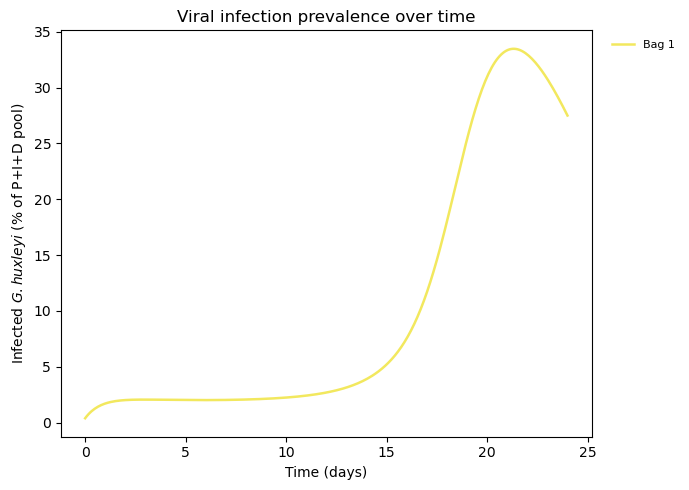

In [66]:
from scipy.integrate import cumulative_trapezoid

_post = trace.posterior
param_medians = {name: float(_post[name].median()) for name in PARAM_ORDER}
params_med = [param_medians[name] for name in PARAM_ORDER]

# Posterior-median initial conditions for this bag's fit.
# LATER (multi-bag loop): replace these with bag-specific first observations,
# as in bag_df.loc[...].sort_values('Day')['Abundance'].iloc[0], keeping
# params_med shared across bags but y0_bag swapped per bag.
y0_med = [float(_post[name].median()) for name in ["P0", "I0", "D0", "B0", "V0", "Z0"]]


def solve_full_trajectory(t_dense, y0, params, ode_func=general_case):
    """Same LSODA -> BDF fallback pattern used in SolveIVPWrapper / posterior_predictive_bands."""
    t_span = (float(t_dense.min()), float(t_dense.max()))
    for method in ("LSODA", "BDF"):
        try:
            sol = solve_ivp(ode_func, t_span, y0, t_eval=t_dense, method=method,
                             args=(params,), rtol=1e-6, atol=1e-8)
            if sol.success and np.all(np.isfinite(sol.y)):
                return sol
        except Exception:
            continue
    return None


def decompose_death_terms(t, sol_y, params):
    """Cumulative contribution of each P-loss term in general_case's dPdt."""
    P, I, D, B, V, Z = np.maximum(sol_y, 0.0)
    mu_P, k_P, delta_P, mu_B, k_B, beta_B, rho, lambda_D, beta_V, phi_V, k_V, Gmax, k_m, theta_Z, lambda_I = params

    phi_B = rho * (D + I)
    graz = Gmax * P / (k_m + P) * Z

    flux_nat  = delta_P * P
    flux_bact = phi_B * P * B
    flux_vir  = phi_V * P * V
    flux_zoop = graz

    D_nat  = cumulative_trapezoid(flux_nat,  t, initial=0.0)
    D_bact = cumulative_trapezoid(flux_bact, t, initial=0.0)
    D_vir  = cumulative_trapezoid(flux_vir,  t, initial=0.0)
    D_zoop = cumulative_trapezoid(flux_zoop, t, initial=0.0)

    # "Ever dead" pool feeding the D compartment (undecayed natural + bacterial losses)
    D_total = D_nat + D_bact

    return {
        't': t, 'P': P, 'I': I, 'D_total': D_total,
        'D_nat': D_nat, 'D_bact': D_bact, 'D_vir': D_vir, 'D_zoop': D_zoop,
    }


sol = solve_full_trajectory(t_dense, y0_med, params_med)
if sol is None:
    raise RuntimeError("Posterior-median solve failed -- check params_med / y0_med.")

curves = decompose_death_terms(sol.t, sol.y, params_med)


# ---------------------------------------------------------------------
# 1. Death fractionation over time (stacked area of each P-loss term)
# ---------------------------------------------------------------------
colors = ['#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00', '#CC79A7', '#000000']

fig, ax = plt.subplots(figsize=(2, 3))
ax.stackplot(curves['t'], curves['D_nat'], curves['D_bact'], curves['D_vir'], curves['D_zoop'],
             labels=['Natural', 'Bacterial', 'Viral', 'Grazing'],
             colors=[colors[5], colors[4], colors[6], colors[0]])
# ax.set_title('Bag 1', fontsize=10)  # LATER: f'{bag_id} ({treat})' once looping
ax.set_xlabel('Time (days)', fontsize=8)
ax.set_ylabel(r'$\it{G. huxleyi}$ death (cells mL$^{-1}$)', fontsize=8)
ax.ticklabel_format(style='sci', scilimits=(0, 0), axis='y')
plt.xticks(fontsize=6)
plt.yticks(fontsize=6)
ax.legend(loc='best', frameon=False, fontsize=6)
plt.tight_layout()
plt.savefig('figures/bag5_death_signature.pdf', dpi=600, bbox_inches='tight')
plt.savefig('figures/bag5_death_signature.png', dpi=600, bbox_inches='tight')
plt.show()


# ---------------------------------------------------------------------
# 2. Infection prevalence over time
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5))

total_pool = curves['P'] + curves['I'] + curves['D_total']
infected_pct = 100 * curves['I'] / (total_pool + 1e-30)

ax.plot(curves['t'], infected_pct, color=colors[3], lw=1.8, alpha=0.85, label='Bag 1')

ax.set_xlabel('Time (days)')
ax.set_ylabel(r'Infected $\it{G. huxleyi}$ (% of P+I+D pool)')
ax.set_title('Viral infection prevalence over time')
ax.legend(fontsize=8, frameon=False, loc='upper left', bbox_to_anchor=(1.02, 1.0))
plt.tight_layout()
# plt.savefig('figures/bag1_infected_percentage.png', dpi=300, bbox_inches='tight')
plt.show()